In [2]:
import pandas as pd 
import numpy as np


%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree


from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler 
from sklearn import metrics

In [14]:
data = pd.read_csv('heart_2020_cleaned.csv')
data.head(6)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
5,Yes,28.87,Yes,No,No,6.0,0.0,Yes,Female,75-79,Black,No,No,Fair,12.0,No,No,No


In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load the dataset
data = pd.read_csv('heart_2020_cleaned.csv')

# 2. Clean binary 'Yes' / 'No' columns to 1 and 0 (integers, NOT strings!)
binary_cols = [
    'HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 
    'DiffWalking', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer'
]
for col in binary_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

# 3. Clean 'Sex' and 'Diabetic' columns
data['Sex'] = data['Sex'].map({'Male': 1, 'Female': 0})
data['Diabetic'] = data['Diabetic'].replace({
    'Yes': 1, 
    'Yes (during pregnancy)': 1, 
    'No': 0, 
    'No, borderline diabetes': 0
})

# 4. Ordinal encoding for AgeCategory and GenHealth (preserves true ranking!)
label_encoder = LabelEncoder()
data['AgeCategory'] = label_encoder.fit_transform(data['AgeCategory'])
data['GenHealth'] = label_encoder.fit_transform(data['GenHealth'])

# 5. One-hot encode ONLY 'Race' to avoid artificial ranking (adds just 5 columns)
data = pd.get_dummies(data, columns=['Race'], drop_first=True)

# 6. Separate features (X) and target (y)
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

# 7. Scale all features using StandardScaler (exactly like in puma.ipynb)
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X)

# 8. Create the clean data_scaled DataFrame
data_scaled = pd.DataFrame(X_scaled_values, columns=X.columns)
data_scaled['HeartDisease'] = y.values  # Add target back as unscaled 0/1 integers

print("Data cleaning and scaling complete. Shape:", data_scaled.shape)
data_scaled.info()
data_scaled.head(30)

Data cleaning and scaling complete. Shape: (319795, 22)
<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   BMI               319795 non-null  float64
 1   Smoking           319795 non-null  float64
 2   AlcoholDrinking   319795 non-null  float64
 3   Stroke            319795 non-null  float64
 4   PhysicalHealth    319795 non-null  float64
 5   MentalHealth      319795 non-null  float64
 6   DiffWalking       319795 non-null  float64
 7   Sex               319795 non-null  float64
 8   AgeCategory       319795 non-null  float64
 9   Diabetic          319795 non-null  float64
 10  PhysicalActivity  319795 non-null  float64
 11  GenHealth         319795 non-null  float64
 12  SleepTime         319795 non-null  float64
 13  Asthma            319795 non-null  float64
 14  KidneyDisease     319795 non-null  float64
 15  SkinCancer        31979

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Diabetic,...,SleepTime,Asthma,KidneyDisease,SkinCancer,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,HeartDisease
0,-1.844750,1.193474,-0.27032,-0.198040,-0.046751,3.281069,-0.401578,-0.951711,0.136184,2.524911,...,-1.460354,2.541515,-0.195554,3.118419,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
1,-1.256338,-0.837890,-0.27032,5.049478,-0.424070,-0.490039,-0.401578,-0.951711,1.538806,-0.396054,...,-0.067601,-0.393466,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
2,-0.274603,1.193474,-0.27032,-0.198040,2.091388,3.281069,-0.401578,1.050739,0.697233,2.524911,...,0.628776,2.541515,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
3,-0.647473,-0.837890,-0.27032,-0.198040,-0.424070,-0.490039,-0.401578,-0.951711,1.258282,-0.396054,...,-0.763977,-0.393466,-0.195554,3.118419,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
4,-0.726138,-0.837890,-0.27032,-0.198040,3.097572,-0.490039,2.490174,-0.951711,-0.705388,-0.396054,...,0.628776,-0.393466,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
5,0.085682,1.193474,-0.27032,-0.198040,0.330568,-0.490039,2.490174,-0.951711,1.258282,-0.396054,...,3.414282,-0.393466,-0.195554,-0.320675,-0.160878,3.597375,-0.3064,-0.188098,-1.813222,1
6,-1.053383,-0.837890,-0.27032,-0.198040,1.462524,-0.490039,-0.401578,-0.951711,0.977757,-0.396054,...,-2.156730,2.541515,-0.195554,3.118419,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
7,0.521484,1.193474,-0.27032,-0.198040,0.204795,-0.490039,2.490174,-0.951711,1.538806,2.524911,...,1.325152,2.541515,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
8,-0.295055,-0.837890,-0.27032,-0.198040,-0.424070,-0.490039,-0.401578,-0.951711,1.538806,-0.396054,...,-1.460354,-0.393466,5.113667,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0
9,1.945316,-0.837890,-0.27032,-0.198040,-0.424070,-0.490039,2.490174,1.050739,0.697233,-0.396054,...,2.021529,-0.393466,-0.195554,-0.320675,-0.160878,-0.277980,-0.3064,-0.188098,0.551505,0


C:\Users\rares\AppData\Local\Temp\ipykernel_23728\3250995244.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='HeartDisease', data=data_scaled, palette='Set2')


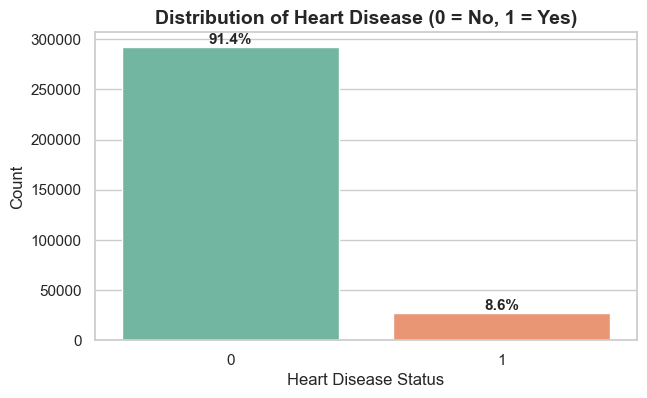

In [15]:

# Set figure style
sns.set_theme(style="whitegrid")

# Distribution of Heart Disease
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='HeartDisease', data=data_scaled, palette='Set2')
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)', fontsize=14, fontweight='bold')
plt.xlabel('Heart Disease Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add percentage labels on top of bars
total = len(data_scaled)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()


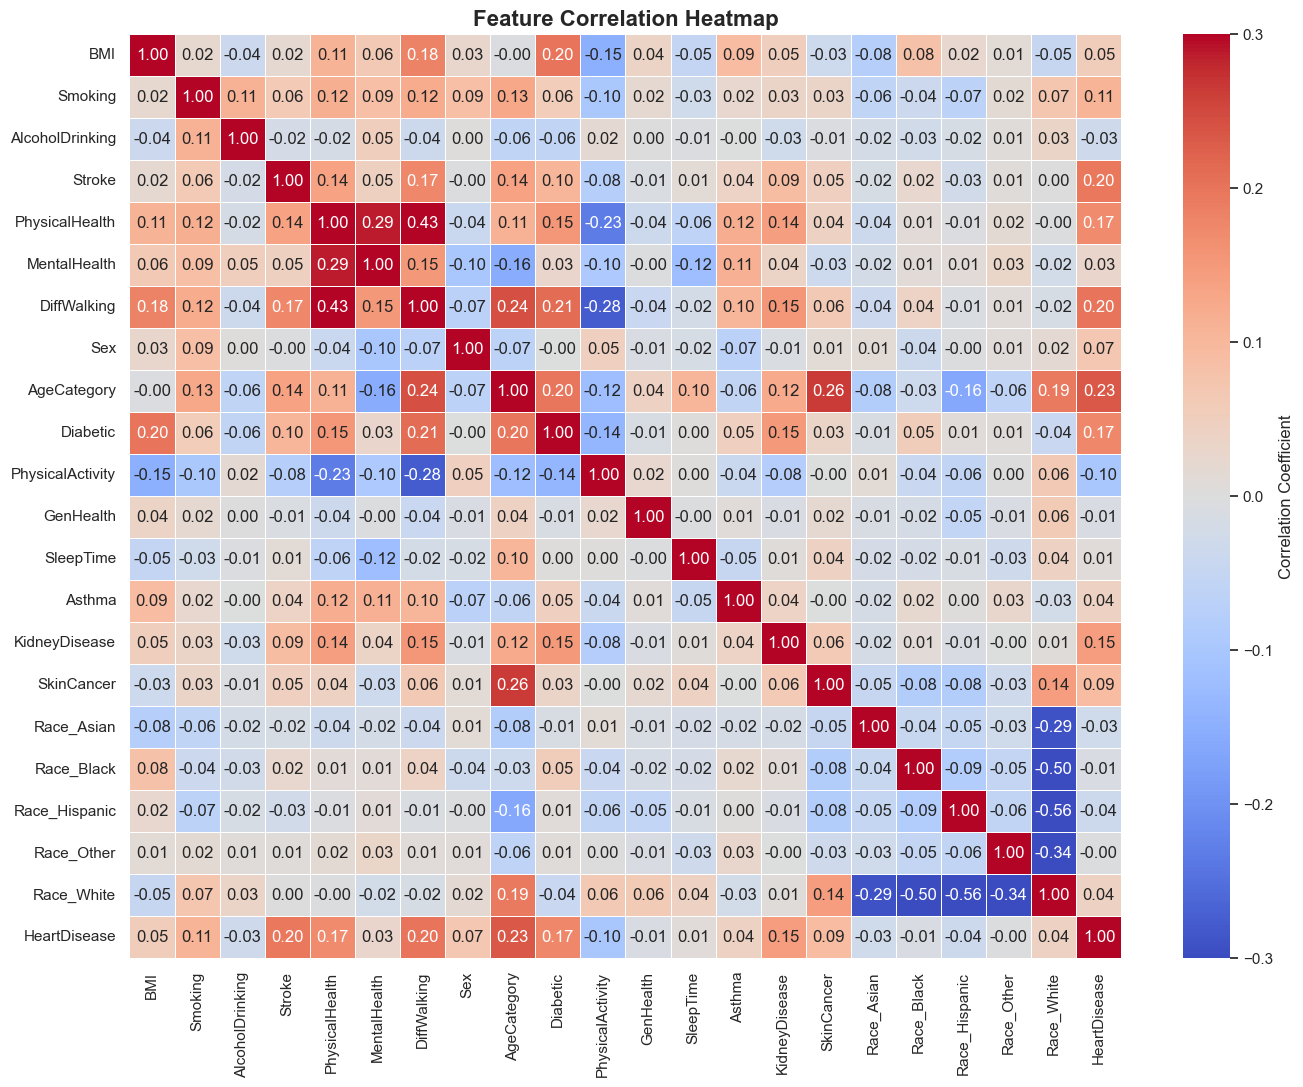

In [16]:

# Correlation Heatmap
plt.figure(figsize=(16, 12))
corr = data_scaled.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.3, vmax=0.3, 
            cbar_kws={'label': 'Correlation Coefficient'}, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
import time
from sklearn import svm

# Baseline SVM Run with Timing
print("Running baseline SVM...")

# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled_values, y, test_size=0.3, random_state=42)

start_time = time.time()

# Initialize and train the model (using default parameters)
clf = svm.SVC(kernel='linear', C=0.65)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

end_time = time.time()
execution_time = end_time - start_time

accuracy = metrics.accuracy_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

print(f"--- SVM Execution Results ---")
print(f"Time taken: {execution_time:.6f} seconds")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

Running baseline SVM...
--- SVM Execution Results ---
Time taken: 1218.854301 seconds
Accuracy: 91.36%
Recall: 0.00%


In [19]:
import time
from sklearn import svm

# Baseline SVM Run with Timing
print("Running baseline SVM...")

# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled_values, y, test_size=0.3, random_state=42)

start_time = time.time()

# Initialize and train the model (using default parameters)
clf = svm.SVC(kernel='linear',class_weight='balanced', C=0.65)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

end_time = time.time()
execution_time = end_time - start_time

accuracy = metrics.accuracy_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)

print(f"--- SVM Execution Results ---")
print(f"Time taken: {execution_time:.6f} seconds")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

Running baseline SVM...
--- SVM Execution Results ---
Time taken: 2439.171343 seconds
Accuracy: 72.91%
Recall: 78.29%
